In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
from optbinning import OptimalBinning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm

In [2]:
df = pd.read_csv("../data/credit_risk_dataset.csv", sep=',')
df = df[df["person_age"]<=100]
df = df[(df["person_emp_length"]<=41)|(df["person_emp_length"].isna())]

In [3]:
column_num = df.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df.select_dtypes(include=['object']).columns.drop('loan_grade')

In [ ]:
for col in column_num:
    plt.figure()
    df[df['loan_status']==0][col].plot(kind='density', label='Non défaut')
    df[df['loan_status']==1][col].plot(kind='density', label='défaut')
    plt.title(f'Densité de {col} selon la classe cible')
    plt.xlabel(col)
    plt.legend()
    plt.show()

In [5]:
ks_results = []

for col in column_num:
    # Séparer les groupes
    data0 = df[df['loan_status'] == 0][col].dropna()
    data1 = df[df['loan_status'] == 1][col].dropna()
    
    # Test KS
    stat, p_value = ks_2samp(data0, data1)
    
    ks_results.append({
        'variable': col,
        'KS_stat': stat,
        'p_value': p_value
    })

ks_df = pd.DataFrame(ks_results).sort_values(by='KS_stat', ascending=False)
print(ks_df)

## Les distributions ne sont pas indentiques (p_value < 0,05)

                     variable   KS_stat       p_value
5         loan_percent_income  0.351535  0.000000e+00
4               loan_int_rate  0.335609  0.000000e+00
1               person_income  0.280457  0.000000e+00
3                   loan_amnt  0.116821  1.617359e-66
2           person_emp_length  0.111786  9.660752e-59
0                  person_age  0.034802  2.784286e-06
6  cb_person_cred_hist_length  0.029066  1.640317e-04


## SPLIT_TRAIN_TEST

In [6]:
df['label_loan_status'] = df['loan_status'].astype('category')
df["stratify_col"] = df["label_loan_status"].astype(str) + "_" + df["person_home_ownership"].astype(str) + "_" + df["loan_intent"].astype(str) + "_" + df["cb_person_default_on_file"].astype(str)
df = df.drop(columns=["label_loan_status"])

In [7]:
counts = df["stratify_col"].value_counts()
rare_labels = counts[counts < 2].index
df["stratify_col"] = df["stratify_col"].replace(rare_labels, "Other")

In [8]:
df_train_set, df_test_set = train_test_split(df, test_size=0.2, stratify=df["stratify_col"], random_state=42)
df_train_set = df_train_set.drop(columns=["stratify_col"])
df_test_set = df_test_set.drop(columns=["stratify_col"])

In [9]:
print((df_train_set["loan_status"].value_counts())/len(df_train_set))
print((df_test_set["loan_status"].value_counts())/len(df_test_set))
(df["loan_status"].value_counts())/len(df)

loan_status
0    0.781803
1    0.218197
Name: count, dtype: float64
loan_status
0    0.781888
1    0.218112
Name: count, dtype: float64


loan_status
0    0.78182
1    0.21818
Name: count, dtype: float64

## Exploration de la base de donnée

In [10]:
df_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26059 entries, 20061 to 18759
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  26059 non-null  int64  
 1   person_income               26059 non-null  int64  
 2   person_home_ownership       26059 non-null  object 
 3   person_emp_length           25346 non-null  float64
 4   loan_intent                 26059 non-null  object 
 5   loan_grade                  26059 non-null  object 
 6   loan_amnt                   26059 non-null  int64  
 7   loan_int_rate               23575 non-null  float64
 8   loan_status                 26059 non-null  int64  
 9   loan_percent_income         26059 non-null  float64
 10  cb_person_default_on_file   26059 non-null  object 
 11  cb_person_cred_hist_length  26059 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.6+ MB


In [11]:
column_num = df_train_set.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df_train_set.select_dtypes(include=['object']).columns.drop('loan_grade')
df_train_set.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,26059.000000,2.605900e+04,25346.000000,26059.000000,23575.000000,26059.000000,26059.000000,26059.000000
mean,27.719368,6.591008e+04,4.778663,9620.019955,11.015313,0.218197,0.170618,5.808857
std,6.193619,5.182004e+04,4.018198,6360.799611,3.236190,0.413030,0.106805,4.047377
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.840000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.905000e+04,7.000000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,94.000000,1.900000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
df_train_set_del_missing_variable = df_train_set[(~df_train_set['loan_int_rate'].isna())&(~df_train_set['person_emp_length'].isna())].copy()
df_train_set_del_loan_int_rate = df_train_set[~df_train_set['loan_int_rate'].isna()].copy()
df_train_set_del_person_emp_length = df_train_set[~df_train_set['person_emp_length'].isna()].copy()

## Discrétisation_ 1

In [12]:
dff = df_train_set.copy()

In [ ]:
## Variable Age
def cat_age(data:pd.DataFrame, nb_classe:int) -> pd.DataFrame:    ## Tester avec 3 et 2 classes
    if nb_classe==3:
        conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 28.50,
                  ((data["person_age"] >= 22.50) & (data["person_age"] < 28.50))             
              ]
        choix_age = ["Jeunes instables", "seniors", "Jeunes"]
        data["classe_age"] = np.select(conditions_age, choix_age, default=None)  
    elif nb_classe==2:
         conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 22.50          
              ]
         choix_age = ["Juniors", "seniors"]
         data["classe_age_2"] = np.select(conditions_age, choix_age, default=None)
    return data

def cat_income(data):
    conditions_income = [data["person_income"] < 22806.00,
                     data["person_income"] >= 79993.50,
                     (data["person_income"] >= 59853.50) & (data["person_income"] < 79993.50),
                     (data["person_income"] >= 34990.00) & (data["person_income"] < 59853.50),
                     (data["person_income"] >= 22806.00) & (data["person_income"] < 34990.00)                               
              ]
    choix_income = ["(-inf, 22806.00)", "[79993.50, inf)", "[59853.50, 79993.50)", "[34990.00, 59853.50)", "[22806.00, 34990.00)"]
    data["classe_income"] = np.select(conditions_income, choix_income, default=None) # Relation monotone décroissante
    return data

def cat_emp_length(data, nb_classe):
    if nb_classe == 5:
        conditions_emp = [data["person_emp_length"].isna(),
                  data["person_emp_length"] < 1.50,
                  data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]

        choix_emp = ["Missing","(-inf, 1.50)", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
        data["classe_emp"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante
    elif nb_classe == 4:
        conditions_emp = [(data["person_emp_length"].isna())|(data["person_emp_length"] < 1.50),  # 2 ème cas : je regroupe les sans_emploi et courte durée d'emploi              
                 data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]
        choix_emp = ["no_emp et < 1.50", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
        data["classe_emp_2"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_emp_length_imputed(data, nb_classe):
    if nb_classe == 4:
        conditions_emp = [data["emp_imputed"] < 2.50,
                  data["emp_imputed"] >= 7.50,
                  (data["emp_imputed"] >= 4.50) & (data["emp_imputed"] < 7.50),
                  (data["emp_imputed"] >= 2.50) & (data["emp_imputed"] < 4.50)
              ]

        choix_emp = ["(-inf, 2.50)", "[7.50, inf)", "[4.50, 7.50)", "[2.50, 4.50)"]
        data["classe_emp_imp_4"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante
    elif nb_classe == 3:
        conditions_emp = [data["emp_imputed"] < 2.50,        
                 data["emp_imputed"] >= 7.50,
                  (data["emp_imputed"] >= 2.50) & (data["emp_imputed"] < 7.50)
              ]
        choix_emp = ["(-inf, 2.50)", "[7.50, inf)", "[2.50, 7.50)"]
        data["classe_emp_imp_3"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_amnt(data):
    conditions_amnt = [data["loan_amnt"] < 5012.50,
                     data["loan_amnt"] >= 18087.50,
                     (data["loan_amnt"] >= 14062.50) & (data["loan_amnt"] < 18087.50),
                     (data["loan_amnt"] >= 7487.50) & (data["loan_amnt"] < 14062.50),
                     (data["loan_amnt"] >= 5012.50) & (data["loan_amnt"] < 7487.50)                               
              ]

    choix_amnt = ["(-inf, 5012.50)", "[18087.50, inf)", "[14062.50, 18087.50)", "[7487.50, 14062.50)", "[5012.50, 7487.50)"]
    data["classe_amnt"] = np.select(conditions_amnt, choix_amnt, default=None)  # Relation en U (tester un autre regroupement si ce n'est pas significatif)
    return data

def cat_int_rate(data):
    conditions_int_rate = [data["loan_int_rate"].isna(),
                     data["loan_int_rate"] < 7.89,
                     data["loan_int_rate"] >= 15.28,
                     (data["loan_int_rate"] >= 14.37) & (data["loan_int_rate"] < 15.28),
                     (data["loan_int_rate"] >= 12.07) & (data["loan_int_rate"] < 14.37),
                     (data["loan_int_rate"] >= 7.89) & (data["loan_int_rate"] < 12.07)                               
              ]

    choix_int_rate = ["Missing","(-inf, 7.89)", "[15.28, inf)", "[14.37, 15.28)", "[12.07, 14.37)", "[7.89, 12.07)"]
    data["classe_int_rate"] = np.select(conditions_int_rate, choix_int_rate, default=None)  # Relation monotone croissante
    return data

def cat_percent_income(data):
    conditions_percent_income = [data["loan_percent_income"] < 0.16,
                     data["loan_percent_income"] >= 0.31,
                     (data["loan_percent_income"] >= 0.25) & (data["loan_percent_income"] < 0.31),
                     (data["loan_percent_income"] >= 0.16) & (data["loan_percent_income"] < 0.25)                               
              ]

    choix_percent_income = ["(-inf, 0.16)", "[0.31, inf)", "[0.25, 0.31)", "[0.16, 0.25)"]
    data["classe_percent_income"] = np.select(conditions_percent_income, choix_percent_income, default=None) # Relation monotone croissante
    return data

def cat_cred_hist_length(data):
    conditions_cred_hist = [data["cb_person_cred_hist_length"] < 2.50,
                     data["cb_person_cred_hist_length"] >= 4.50,
                     (data["cb_person_cred_hist_length"] >= 2.50) & (data["cb_person_cred_hist_length"] < 4.50)                               
              ]

    choix_cred_hist = ["(-inf, 2.50)", "[4.50, inf)", "[2.50, 4.50)"]
    data["classe_cred_hist"] = np.select(conditions_cred_hist, choix_cred_hist, default=None)
    return data


In [ ]:
## Age
dff = cat_age(dff, 3) # IV : 0.01 < 0.02 inutile dans le modèle
# dff = cat_age(dff, 2)

## Variable person_income
dff = cat_income(dff)  # IV : 0.563203

## person_emp_length
dff = cat_emp_length(dff, 5) # IV : 0.069434
#dff = cat_emp_length(dff, 4)

## emp_imputed
dff = cat_emp_length_imputed(dff, 4) # IV : 0.068035
dff = cat_emp_length_imputed(dff, 3)

## loan_amnt
dff = cat_amnt(dff) # IV : 0.085453

## loan_int_rate
dff = cat_int_rate(dff) # IV : 0.665547

## loan_percent_income
dff = cat_percent_income(dff) # IV : 0.943946

## cb_person_cred_hist_length
dff = cat_cred_hist_length(dff) # IV : 0.003482

In [ ]:
# Imputation de emp_length par la médiane 
corr_pearson = dff["person_emp_length"].corr(dff["person_income"], method="pearson")
print("Corrélation de Pearson :", corr_pearson)

Corrélation de Pearson : 0.21565458148187175


In [24]:
# Calcul des médianes de durée d'emploi par bin de revenu
median_emp_by_income = dff.groupby("classe_income")["person_emp_length"].median()

# Fonction d'imputation
def impute_emp(row):
    if pd.isna(row["person_emp_length"]):
        return median_emp_by_income.loc[row["classe_income"]]
    else:
        return row["person_emp_length"]

# Appliquer l’imputation
dff["emp_imputed"] = dff.apply(impute_emp, axis=1)

In [ ]:
print(dff["classe_emp_imp_4"].value_counts())
dff.groupby(dff["classe_emp_imp_4"])["loan_status"].mean()

                 Bin  Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, 2.50)   8815   0.338271       6362   2453    0.278276   
1       [2.50, 4.50)   5452   0.209218       4321   1131    0.207447   
2       [4.50, 7.50)   6475   0.248475       5262   1213    0.187336   
3        [7.50, inf)   5317   0.204037       4428    889    0.167200   
4            Special      0   0.000000          0      0    0.000000   
5            Missing      0   0.000000          0      0    0.000000   
Totals                26059   1.000000      20373   5686    0.218197   

             WoE        IV        JS  
0      -0.323172  0.038501  0.004792  
1       0.064181  0.000846  0.000106  
2       0.191211  0.008595  0.001073  
3       0.329403  0.020093  0.002500  
4            0.0  0.000000  0.000000  
5            0.0  0.000000  0.000000  
Totals            0.068035  0.008471  


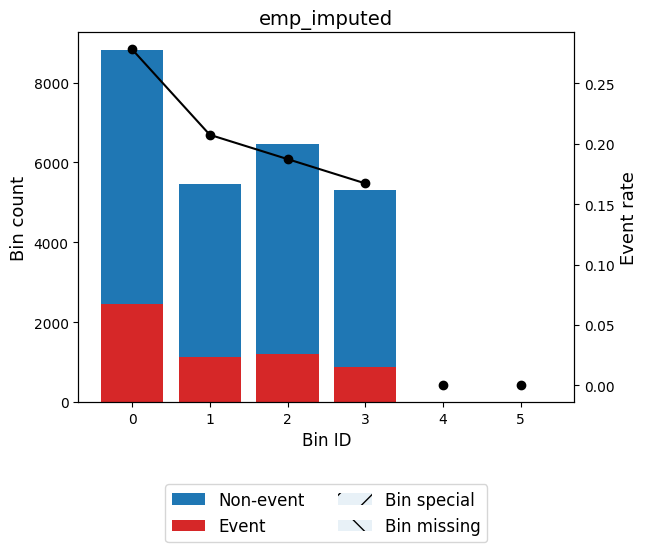

In [46]:
## GROUPEMENT VAR QUANT : L'IV mesure la capacité d’une variable à discriminer les bons et les mauvais payeurs (< 0.02 : inutile).
variable = 'emp_imputed'
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp",
                      min_n_bins=4, max_n_bins=4)  # "cp" = solver par défaut (constraint programming)
optb.fit(dff[variable], dff['loan_status'])

bin_table = optb.binning_table.build()
print(bin_table)
optb.binning_table.plot(metric="event_rate")

In [ ]:
def cat_home_ownership(data):
    data["classe_person_home_ownership"] = np.where((data["person_home_ownership"]=='OTHER')|(data["person_home_ownership"]=='RENT'), "[OTHER, RENT]", data["person_home_ownership"])
    return data

def cat_loan_intent(data):
    data["classe_loan_intent"] = np.where((data["loan_intent"]=='HOMEIMPROVEMENT')|(data["loan_intent"]=='MEDICAL'), "[HOMEIMPROVEMENT, MEDICAL]", data["loan_intent"])
    return data

def cat_loan_intent_2(data):
    data["classe_loan_intent_2"] = np.where((data["loan_intent"]=='HOMEIMPROVEMENT')|(data["loan_intent"]=='MEDICAL')|(data["loan_intent"]=='DEBTCONSOLIDATION'),
                                           "[HOMEIMPROVEMENT, MEDICAL]", data["loan_intent"])
    return data

In [ ]:
#######  VARIABLES QUALITATIVES ###################################
## person_home_ownership
dff = cat_home_ownership(dff)

## loan_intent
dff = cat_loan_intent(dff) # 0.095697
dff = cat_loan_intent_2(dff)

## cb_person_default_on_file
# Pour l'instant on ne touche pas  # 0.164053

In [ ]:
## GROUPEMENT VAR QUAL
var = "classe_loan_intent"
print((dff[var].value_counts())/len(dff))
dff.groupby(dff[var])["loan_status"].mean()

In [65]:
variable = 'loan_intent'
optb = OptimalBinning(name=variable, dtype='categorical', max_n_bins=4)
optb.fit(dff[variable], dff['loan_status'])
print(optb.binning_table.build())   # voir les groupes, WoE, IV

                                                  Bin  Count  Count (%)  \
0                                           [VENTURE]   4572   0.175448   
1                                         [EDUCATION]   5160   0.198012   
2                                          [PERSONAL]   4417   0.169500   
3       [HOMEIMPROVEMENT, MEDICAL, DEBTCONSOLIDATION]  11910   0.457040   
4                                             Special      0   0.000000   
5                                             Missing      0   0.000000   
Totals                                                 26059   1.000000   

        Non-event  Event  Event rate       WoE        IV        JS  
0            3895    677    0.148075  0.473574  0.034154  0.004230  
1            4271    889    0.172287  0.293303  0.015630  0.001947  
2            3539    878    0.198777  0.117749  0.002272  0.000284  
3            8668   3242    0.272208 -0.292756  0.042364  0.005277  
4               0      0    0.000000       0.0  0.0000

## ETUDES DES CORRELATIONS ENTRE LES VARIABLES

In [67]:
dff.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'classe_age',
       'classe_income', 'classe_emp', 'classe_amnt', 'classe_int_rate',
       'classe_percent_income', 'classe_cred_hist', 'classe_age_2',
       'emp_imputed', 'classe_emp_imp_4', 'classe_emp_imp_3',
       'classe_loan_intent', 'classe_person_home_ownership',
       'classe_loan_intent_2'],
      dtype='object')

In [ ]:
## Variables avec lesquelles on fait le régression logistique dans R (pour voir la significativité des coefficicents)
dff_reg = dff[['loan_status','classe_age','classe_income', 'classe_emp', 'classe_amnt','classe_int_rate', 'classe_percent_income', 'classe_cred_hist',
               'classe_age_2','classe_emp_imp_4', 'classe_emp_imp_3','classe_loan_intent','classe_person_home_ownership','loan_intent','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

# Exportation de la table pour l'utiliser dans R
dff_reg.to_csv("F:/personnel/MOSEF Sorbonne/Cours/Modélisation risque de crédit et scoring/df_reg.csv", sep=",", index=False, encoding="utf-8")

In [ ]:
# Variables retenues pour le modèle
dff_reg = dff[['loan_status','classe_income','classe_int_rate', 'classe_percent_income',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

In [ ]:
## Calcul du V_de_Cramer et de la P_value
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    p = chi2_contingency(confusion_matrix)[1]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return [np.sqrt(chi2 / (n * (min(r, k) - 1))), p]

target = 'loan_status'
features = [col for col in dff_reg.columns if col != target]

corr_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
chi2_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
for var1 in features:
    for var2 in features:
        confusion = pd.crosstab(dff_reg[var1], dff_reg[var2])
        chi2_cramer = cramers_v(confusion)
        corr_matrix.loc[var1, var2] = chi2_cramer[0]
        chi2_matrix.loc[var1, var2] = chi2_cramer[1]

# P_value # < 0.05 (on rejette l'indépendance au seuil de 5%)
chi2_matrix

,classe_income,classe_int_rate,classe_percent_income,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
classe_income,0.000000e+00,1.561667e-15,0.000000e+00,0.000000e+00,0.000000e+00,4.553544e-08,2.652674e-01
classe_int_rate,1.561667e-15,0.000000e+00,1.088064e-86,2.013023e-29,3.344119e-112,0.000000e+00,3.159145e-01
classe_percent_income,0.000000e+00,1.088064e-86,0.000000e+00,1.382514e-13,3.627822e-108,1.457595e-10,8.921613e-01
classe_emp_imp_4,0.000000e+00,2.013023e-29,1.382514e-13,0.000000e+00,0.000000e+00,7.167379e-07,9.725104e-14
classe_person_home_ownership,0.000000e+00,3.344119e-112,3.627822e-108,0.000000e+00,0.000000e+00,3.134359e-24,3.319477e-64
cb_person_default_on_file,4.553544e-08,0.000000e+00,1.457595e-10,7.167379e-07,3.134359e-24,0.000000e+00,3.745711e-01
classe_loan_intent_2,2.652674e-01,3.159145e-01,8.921613e-01,9.725104e-14,3.319477e-64,3.745711e-01,0.000000e+00


In [ ]:
# V_de_Cramer (>= 0.5 -> association forte)
corr_matrix

,classe_income,classe_int_rate,classe_percent_income,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
classe_income,1.000000,0.033360,0.194669,0.141089,0.238330,0.039127,0.013656
classe_int_rate,0.033360,1.000000,0.075980,0.047366,0.102914,0.539444,0.014768
classe_percent_income,0.194669,0.075980,1.000000,0.032058,0.099465,0.043263,0.007398
classe_emp_imp_4,0.141089,0.047366,0.032058,1.000000,0.181204,0.034686,0.032210
classe_person_home_ownership,0.238330,0.102914,0.099465,0.181204,1.000000,0.064449,0.077268
cb_person_default_on_file,0.039127,0.539444,0.043263,0.034686,0.064449,0.999868,0.010929
classe_loan_intent_2,0.013656,0.014768,0.007398,0.032210,0.077268,0.010929,1.000000


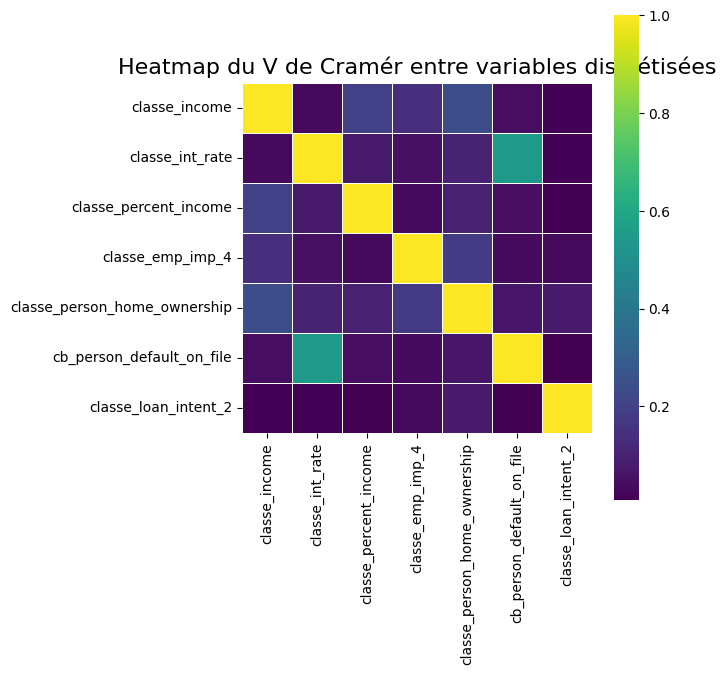

In [74]:
plt.figure(figsize=(7,7))
sns.heatmap(corr_matrix.astype(float),annot=False, cmap="viridis", square=True, linewidths=0.5)
plt.title("Heatmap du V de Cramér entre variables discrétisées", fontsize=16)
plt.tight_layout()
plt.show()

In [75]:
results_chi2_loan_status = []
for var in features:
    confusion = pd.crosstab(dff_reg[var], dff_reg[target])
    n = confusion.sum().sum()
    r, k = confusion.shape
    chi2, p, dof, expected = chi2_contingency(confusion)
    v_cramer = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    results_chi2_loan_status.append({
        'variable': var,
        'chi2': chi2,
        'p_value': p,
        'V_de_cramer' : v_cramer
    })
    
results_chi2_loan_status = pd.DataFrame(results_chi2_loan_status)
results_chi2_loan_status

,variable,chi2,p_value,V_de_cramer
0,classe_income,2674.434023,0.000000e+00,0.320359
1,classe_int_rate,3367.347696,0.000000e+00,0.359472
2,classe_percent_income,5040.381585,0.000000e+00,0.439798
3,classe_emp_imp_4,307.422355,2.462054e-66,0.108615
4,classe_person_home_ownership,1521.821807,0.000000e+00,0.241659
5,cb_person_default_on_file,835.478008,1.044023e-183,0.179056
6,classe_loan_intent_2,408.978624,2.513441e-88,0.125277


- **Age** préféré à **cred_hist** *(IV_age > IV_cred_hist)*
- **loan_int_rate** préféré à **cb_person_default_on_file** *(IV_rate > IV_default_on_file)*

## MODELISATION

In [28]:
#,'classe_cred_hist'
features = [ 'classe_age','classe_income','classe_emp','classe_amnt','classe_int_rate','classe_percent_income','classe_person_home_ownership','loan_intent',
    'cb_person_default_on_file']
target = "loan_status"
X = dff_reg[features]
y = dff_reg[target]

In [95]:
cat_vars = X.columns.tolist()
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_vars)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('logreg', LogisticRegression(max_iter=1000))
])
model.fit(X, y)
print("Score train :", model.score(X, y))

Score train : 0.8727502974020492


In [29]:
## VOIR LES COEFS
cat_vars = X.columns.tolist()

ohe = OneHotEncoder(drop='first', sparse_output=False)
X_final = pd.DataFrame(ohe.fit_transform(X[cat_vars]), columns=ohe.get_feature_names_out(cat_vars), index=X.index)

# Ajouter constante pour statsmodels
X_final = sm.add_constant(X_final)

# =============================
# 3. Fit régression logistique
# =============================
logit_model = sm.Logit(y, X_final)
result = logit_model.fit()

# =============================
# 4. Résultats : coefficients, p-values, odds ratio
# =============================
summary_df = pd.DataFrame({
    'variable': result.params.index,
    'coefficient': result.params.values,
    'p_value': result.pvalues,
    'odds_ratio': result.params.apply(lambda x: round(np.exp(x), 3))
}).sort_values(by='coefficient', ascending=False)

Optimization terminated successfully.
         Current function value: 0.324585
         Iterations 7


In [30]:
summary_df

,variable,coefficient,p_value,odds_ratio
"classe_int_rate_[15.28, inf)","classe_int_rate_[15.28, inf)",3.127664,0.000000e+00,22.821
"classe_percent_income_[0.31, inf)","classe_percent_income_[0.31, inf)",3.061574,3.379873e-219,21.361
"classe_int_rate_[14.37, 15.28)","classe_int_rate_[14.37, 15.28)",2.395710,6.380904e-152,10.976
classe_int_rate_Missing,classe_int_rate_Missing,0.891040,4.259908e-26,2.438
"classe_int_rate_[12.07, 14.37)","classe_int_rate_[12.07, 14.37)",0.885445,7.406730e-33,2.424
"classe_person_home_ownership_[OTHER, RENT]","classe_person_home_ownership_[OTHER, RENT]",0.832473,1.259805e-72,2.299
"classe_int_rate_[7.89, 12.07)","classe_int_rate_[7.89, 12.07)",0.438009,8.370264e-11,1.550
"classe_percent_income_[0.25, 0.31)","classe_percent_income_[0.25, 0.31)",0.424858,6.984811e-07,1.529
"classe_percent_income_[0.16, 0.25)","classe_percent_income_[0.16, 0.25)",0.303621,1.015028e-06,1.355
cb_person_default_on_file_Y,cb_person_default_on_file_Y,0.239333,5.514497e-06,1.270
